In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/SHA256SUMS.txt
/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/Readme.txt
/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/LICENSE.txt
/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/Experiment_1/A2/Right_EDA.csv
/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/Experiment_1/A2/Left_EDA.csv
/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regu

   EEG Frequency Band Analysis using MNE
   Dataset : BrainWear — Muse EEG (TP9, AF7, AF8, TP10)

✅ EEG file loaded.
   Shape   : (1298136, 6)
   Columns : ['timestamps', 'TP9', 'AF7', 'AF8', 'TP10', 'Right AUX']
     timestamps     TP9     AF7     AF8    TP10  Right AUX
0  1.624262e+09  34.180  50.781  34.180 -26.367      5.371
1  1.624262e+09  49.316  50.781  20.996  -8.789    -12.207
2  1.624262e+09  50.293  10.742  15.137  -2.441    -27.832
3  1.624262e+09  44.922 -19.043  16.602 -23.926    -33.203
4  1.624262e+09  19.531  20.020  31.250 -48.340    -30.273

   EEG data shape  : (4, 1298136)  (channels × timepoints)
   Sampling rate   : 256.0 Hz
   Duration        : 5070.84 seconds

✅ MNE Raw object created.
<RawArray | 4 x 1298136 (5070.8 s), ~39.6 MiB, data loaded>

─────────────────────────────────────────────────────────────────
   EEG FREQUENCY BANDS
─────────────────────────────────────────────────────────────────
  Band       Range (Hz)         Associated State
──────────────

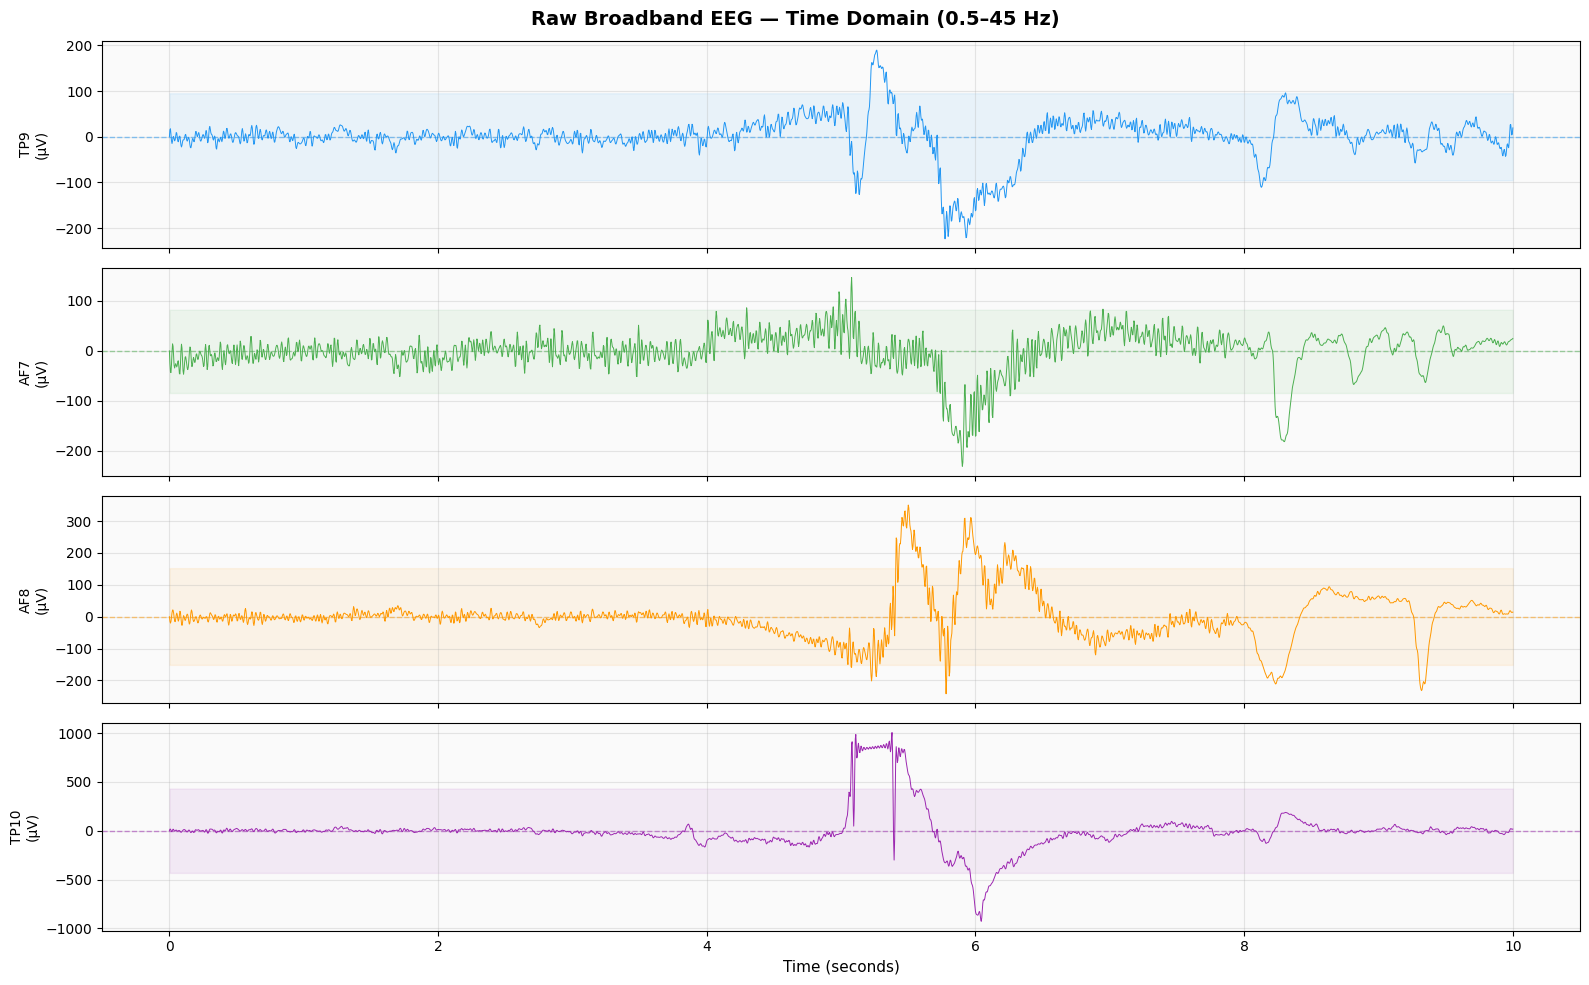

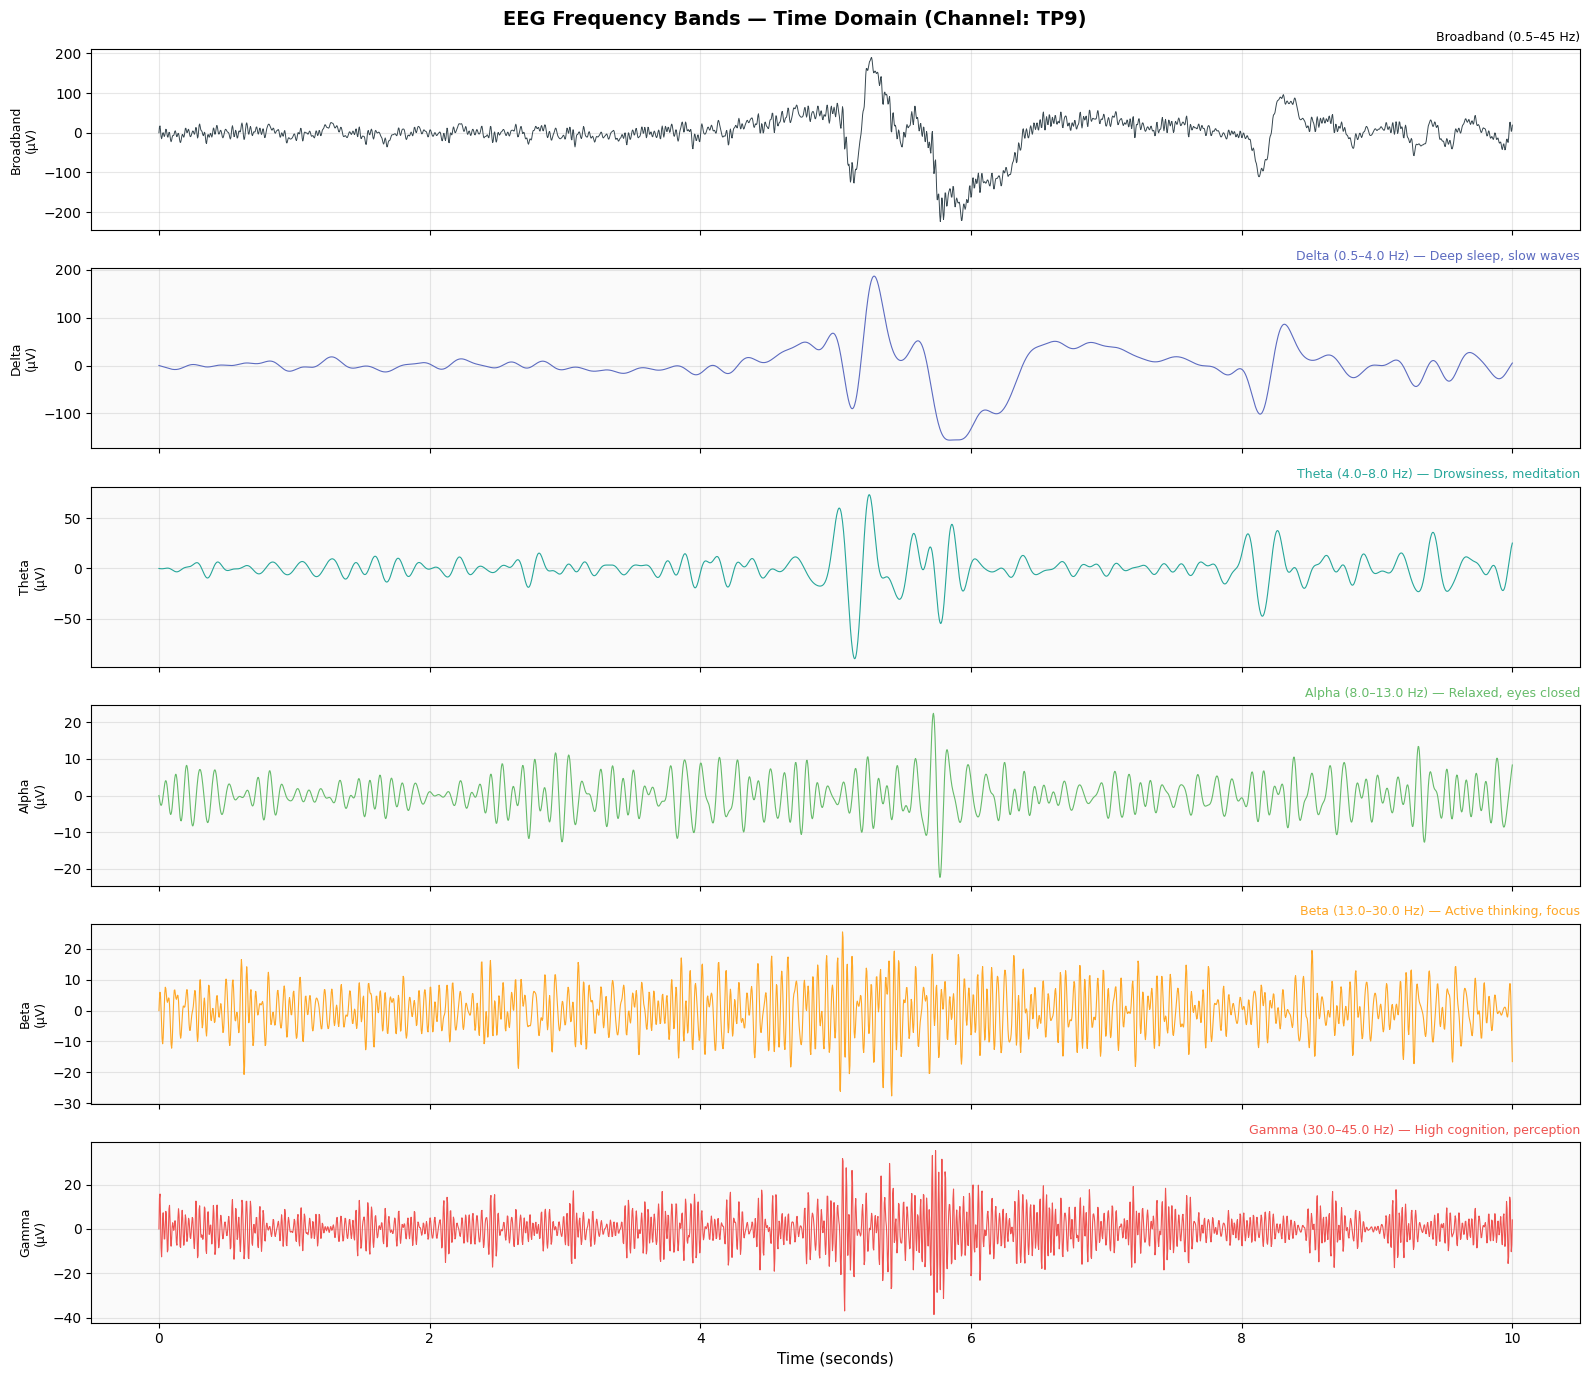


✅ Power Spectral Density computed (Welch method).
   Frequency resolution : 0.500 Hz
   Frequency range      : 0.5 – 45.0 Hz


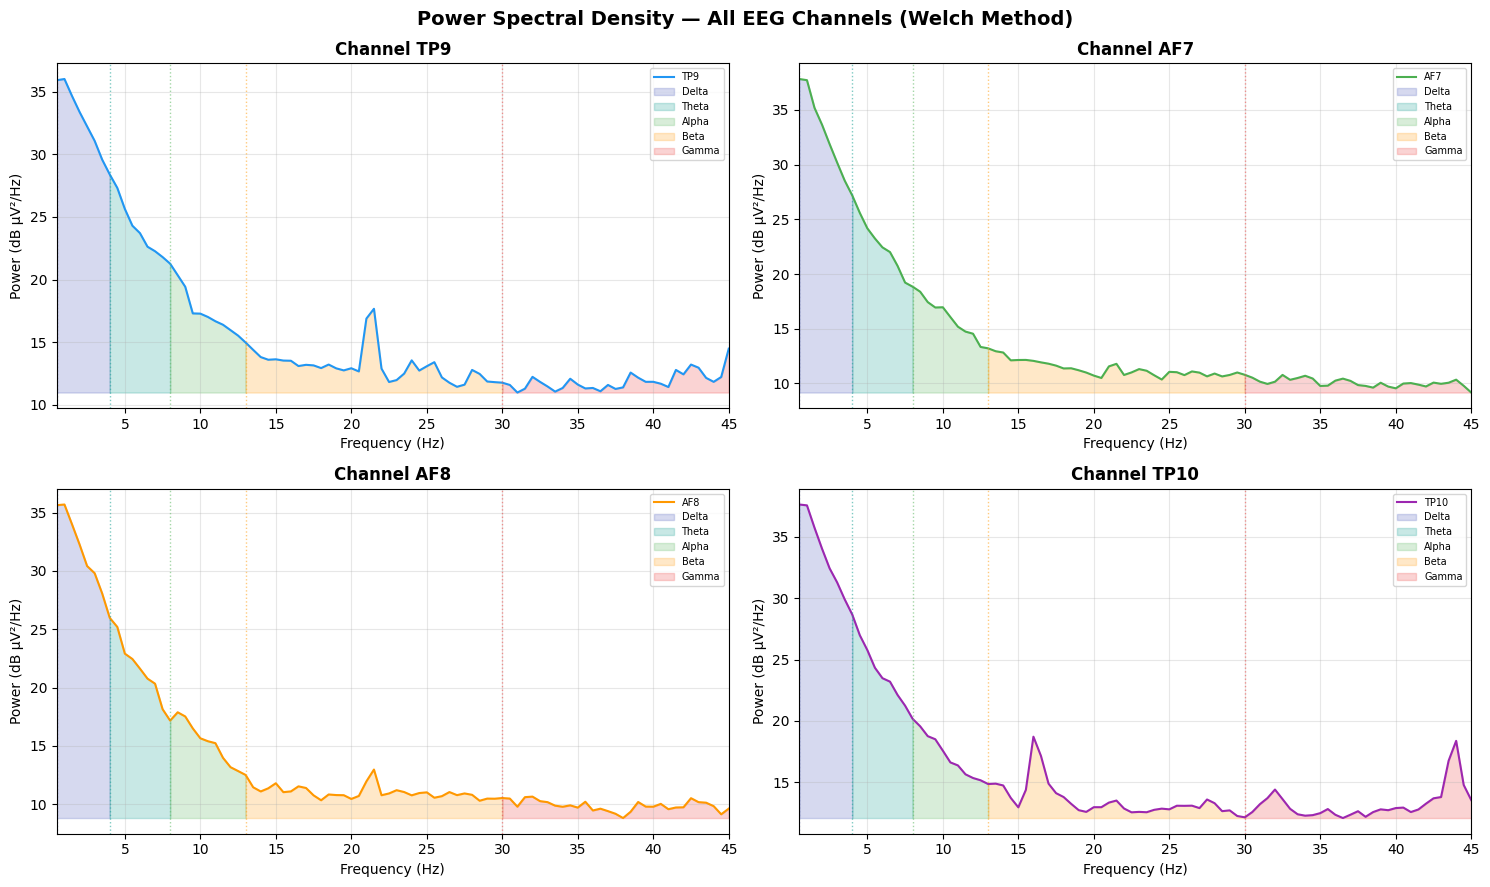

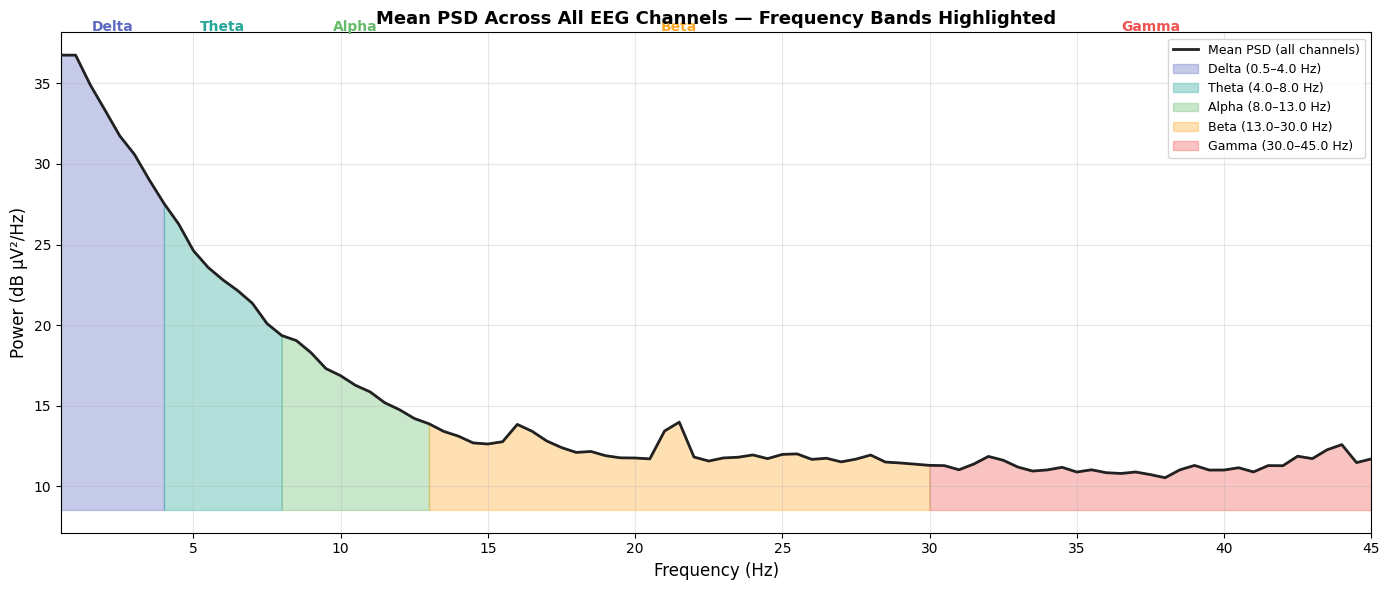


✅ Computing absolute band power per channel...

── Band Power (μV²) per Channel ──
          Delta      Theta     Alpha      Beta     Gamma
TP9   7652.2048  1163.1647  300.2356  364.3782  232.1070
AF7   9043.1345   835.0622  212.7461  234.2113  153.5082
AF8   6308.6634   681.3982  183.5603  216.5765  146.1325
TP10  9639.0126  1147.9626  277.5010  407.4436  337.1617

── Relative Band Power (%) per Channel ──
      Delta  Theta  Alpha  Beta  Gamma
TP9   78.79  11.98   3.09  3.75   2.39
AF7   86.30   7.97   2.03  2.24   1.46
AF8   83.71   9.04   2.44  2.87   1.94
TP10  81.62   9.72   2.35  3.45   2.86


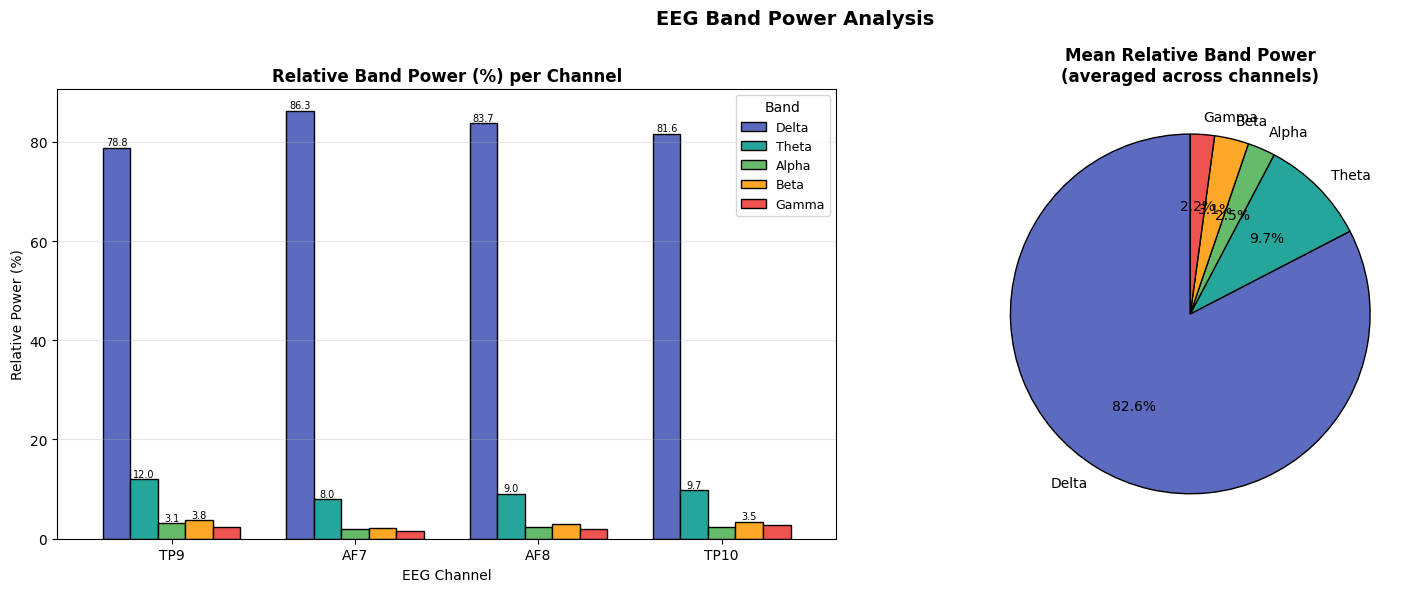


✅ Computing spectrograms (STFT)...


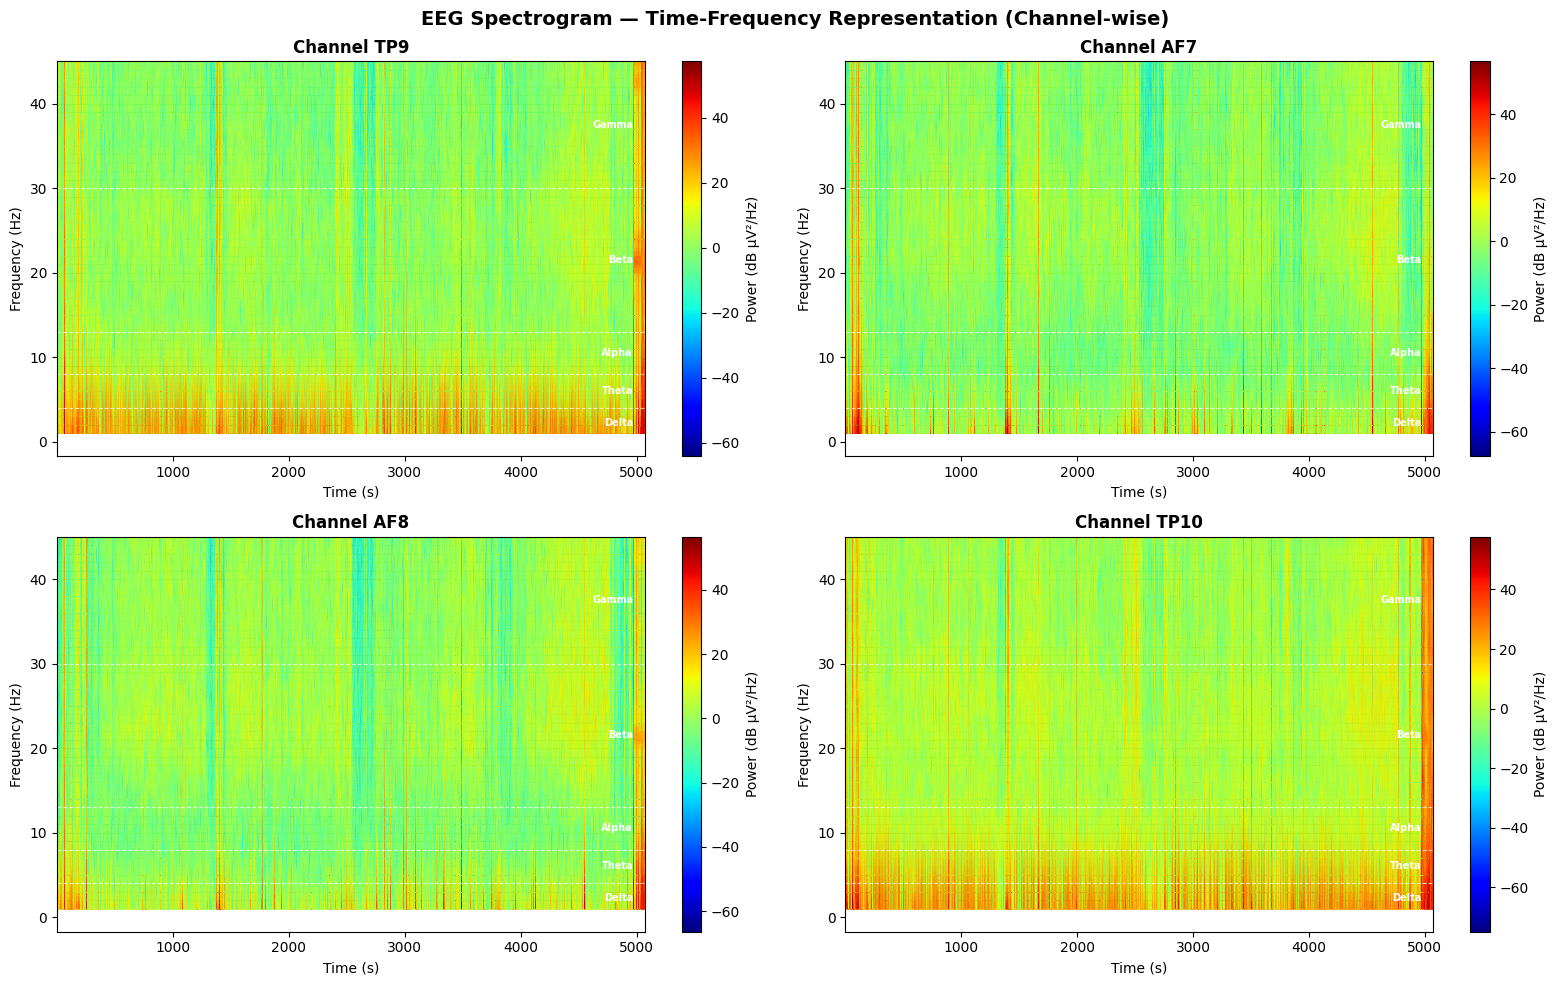


✅ Plotting topographic maps (band power distribution)...


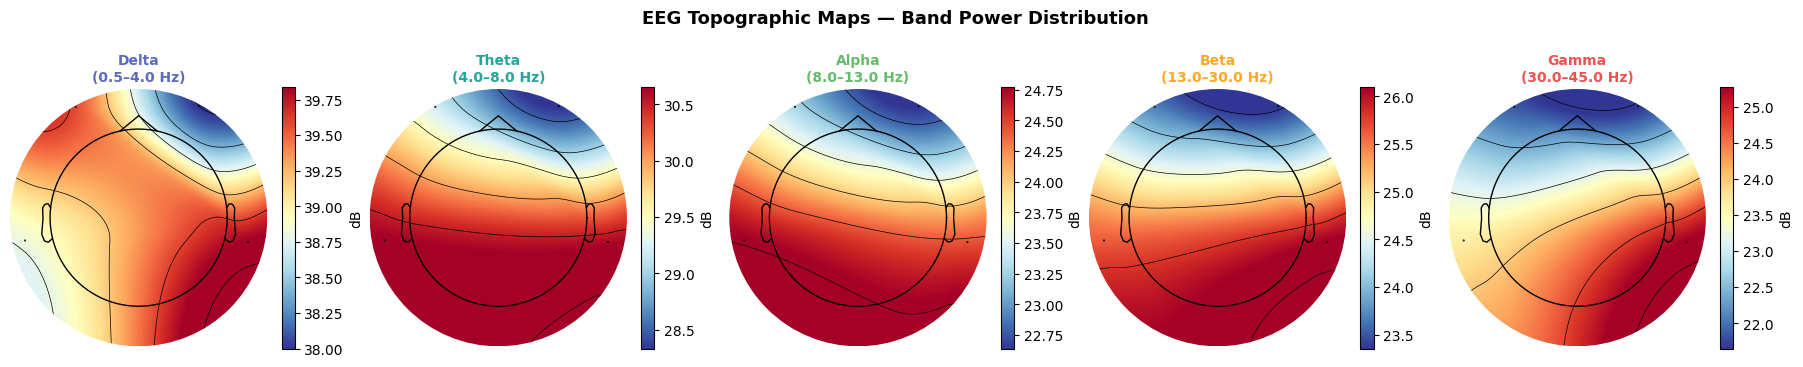


   RESULTS SUMMARY

EEG Signal Details:
  Channels    : TP9, AF7, AF8, TP10
  Sampling Rate: 256.0 Hz
  Duration    : 5070.84 seconds
  Total samples: 1298136

Frequency Band Power (mean across channels):

  Delta    ( 0.5– 4.0 Hz) : 8160.7538 μV²  |  82.6% of total  — Deep sleep, slow waves
  Theta    ( 4.0– 8.0 Hz) : 956.8969 μV²  |  9.7% of total  — Drowsiness, meditation
  Alpha    ( 8.0–13.0 Hz) : 243.5107 μV²  |  2.5% of total  — Relaxed, eyes closed
  Beta     (13.0–30.0 Hz) : 305.6524 μV²  |  3.1% of total  — Active thinking, focus
  Gamma    (30.0–45.0 Hz) : 217.2274 μV²  |  2.2% of total  — High cognition, perception


In [2]:
# ════════════════════════════════════════════════════════════════
#  EEG Frequency Band Extraction & Visualization using MNE
#  Dataset: BrainWear EEG (Muse Headband — 4 channels)
# ════════════════════════════════════════════════════════════════

# ── Install MNE if not available ──
import subprocess
subprocess.run(['pip', 'install', 'mne', '--quiet'], check=False)

import numpy as np
import pandas as pd
import os, warnings
warnings.filterwarnings('ignore')

import mne
mne.set_log_level('WARNING')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal as scipy_signal

print("=" * 65)
print("   EEG Frequency Band Analysis using MNE")
print("   Dataset : BrainWear — Muse EEG (TP9, AF7, AF8, TP10)")
print("=" * 65)

# ════════════════════════════════════════════════════════════════
#  STEP 1 — Load Raw EEG CSV
# ════════════════════════════════════════════════════════════════
BASE_PATH = '/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0'

eeg_path = os.path.join(BASE_PATH,
           'Experiment_1', 'A1', 'EEG_recording.csv')

eeg_df = pd.read_csv(eeg_path)
print(f"\n✅ EEG file loaded.")
print(f"   Shape   : {eeg_df.shape}")
print(f"   Columns : {list(eeg_df.columns)}")
print(eeg_df.head())

# ════════════════════════════════════════════════════════════════
#  STEP 2 — Prepare MNE Raw Object
# ════════════════════════════════════════════════════════════════

# Muse EEG channels & sampling frequency
CH_NAMES = ['TP9', 'AF7', 'AF8', 'TP10']
SFREQ    = 256.0     # Muse headband samples at 256 Hz

# Extract only EEG channels, drop NaNs
eeg_data = eeg_df[CH_NAMES].dropna().values.T   # shape → (4, n_times)

# Convert from μV to Volts (MNE expects Volts)
eeg_data = eeg_data * 1e-6

print(f"\n   EEG data shape  : {eeg_data.shape}  (channels × timepoints)")
print(f"   Sampling rate   : {SFREQ} Hz")
print(f"   Duration        : {eeg_data.shape[1]/SFREQ:.2f} seconds")

# Create MNE Info object
info = mne.create_info(
    ch_names = CH_NAMES,
    sfreq    = SFREQ,
    ch_types = ['eeg'] * 4
)

# Create RawArray
raw = mne.io.RawArray(eeg_data, info)

# Set standard 10-20 montage positions for the 4 channels
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, match_case=False, on_missing='ignore')

print(f"\n✅ MNE Raw object created.")
print(raw)

# ════════════════════════════════════════════════════════════════
#  STEP 3 — Define EEG Frequency Bands
# ════════════════════════════════════════════════════════════════
BANDS = {
    'Delta'  : (0.5,  4.0,  '#5C6BC0', 'Deep sleep, slow waves'),
    'Theta'  : (4.0,  8.0,  '#26A69A', 'Drowsiness, meditation'),
    'Alpha'  : (8.0,  13.0, '#66BB6A', 'Relaxed, eyes closed'),
    'Beta'   : (13.0, 30.0, '#FFA726', 'Active thinking, focus'),
    'Gamma'  : (30.0, 45.0, '#EF5350', 'High cognition, perception'),
}

print("\n" + "─" * 65)
print("   EEG FREQUENCY BANDS")
print("─" * 65)
print(f"  {'Band':<10} {'Range (Hz)':<18} {'Associated State'}")
print("─" * 65)
for band, (lo, hi, col, desc) in BANDS.items():
    print(f"  {band:<10} {f'{lo}–{hi} Hz':<18} {desc}")
print("─" * 65)

# ════════════════════════════════════════════════════════════════
#  STEP 4 — Band-pass Filter Each Band using MNE
# ════════════════════════════════════════════════════════════════
print("\n✅ Applying MNE band-pass filters...")

# First apply a general notch filter (50 Hz power line noise)
raw_filtered = raw.copy().notch_filter(freqs=50.0, method='fir',
                                        fir_window='hamming')

# Apply broadband filter (0.5–45 Hz)
raw_filtered = raw_filtered.filter(l_freq=0.5, h_freq=45.0,
                                    method='fir',
                                    fir_window='hamming')

# Extract band-specific filtered signals
band_signals = {}
for band, (lo, hi, col, desc) in BANDS.items():
    raw_band = raw_filtered.copy().filter(
        l_freq=lo, h_freq=hi,
        method='fir', fir_window='hamming'
    )
    band_signals[band] = raw_band.get_data()   # (4, n_times)
    print(f"   {band:<8} filtered: {lo}–{hi} Hz  ✅")

# Get raw data for time domain plot
raw_data  = raw_filtered.get_data()   # (4, n_times)
times     = np.arange(raw_data.shape[1]) / SFREQ
n_samples = raw_data.shape[1]

# Use first 10 seconds for time-domain plots
T_SHOW = min(10.0, times[-1])
t_mask = times <= T_SHOW
t_plot = times[t_mask]

print(f"\n   Plotting first {T_SHOW:.0f} seconds of signal.")

# ════════════════════════════════════════════════════════════════
#  STEP 5 — TIME DOMAIN VISUALIZATION
#  Plot 1: Raw broadband EEG (all 4 channels)
# ════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
fig1.suptitle('Raw Broadband EEG — Time Domain (0.5–45 Hz)',
              fontsize=14, fontweight='bold')

ch_colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0']
for i, (ch, col) in enumerate(zip(CH_NAMES, ch_colors)):
    sig = raw_data[i, t_mask] * 1e6   # back to μV for display
    axes1[i].plot(t_plot, sig, color=col, linewidth=0.7)
    axes1[i].set_ylabel(f'{ch}\n(μV)', fontsize=10)
    axes1[i].grid(alpha=0.3)
    axes1[i].set_facecolor('#FAFAFA')
    # Shade ±2σ band
    mu, sd = sig.mean(), sig.std()
    axes1[i].axhline(mu,    color=col, linestyle='--', alpha=0.5, linewidth=1)
    axes1[i].fill_between(t_plot, mu-2*sd, mu+2*sd,
                           alpha=0.08, color=col)

axes1[-1].set_xlabel('Time (seconds)', fontsize=11)
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
#  Plot 2: All 5 bands — time domain (channel TP9 only)
# ════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(6, 1, figsize=(16, 14), sharex=True)
fig2.suptitle('EEG Frequency Bands — Time Domain (Channel: TP9)',
              fontsize=14, fontweight='bold')

# Row 0: broadband
sig_broad = raw_data[0, t_mask] * 1e6
axes2[0].plot(t_plot, sig_broad, color='#37474F', linewidth=0.7)
axes2[0].set_ylabel('Broadband\n(μV)', fontsize=9)
axes2[0].set_title('Broadband (0.5–45 Hz)', fontsize=9, loc='right')
axes2[0].grid(alpha=0.3)

# Rows 1–5: each band
for ax, (band, (lo, hi, col, desc)) in zip(axes2[1:], BANDS.items()):
    sig = band_signals[band][0, t_mask] * 1e6
    ax.plot(t_plot, sig, color=col, linewidth=0.8)
    ax.set_ylabel(f'{band}\n(μV)', fontsize=9)
    ax.set_title(f'{band} ({lo}–{hi} Hz) — {desc}',
                 fontsize=9, loc='right', color=col)
    ax.grid(alpha=0.3)
    ax.set_facecolor('#FAFAFA')

axes2[-1].set_xlabel('Time (seconds)', fontsize=11)
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
#  STEP 6 — FREQUENCY DOMAIN VISUALIZATION
#  Power Spectral Density using MNE's built-in PSD
# ════════════════════════════════════════════════════════════════

# Compute PSD using Welch method via MNE
spectrum = raw_filtered.compute_psd(
    method  = 'welch',
    fmin    = 0.5,
    fmax    = 45.0,
    n_fft   = 512,
    n_overlap = 256,
)

freqs  = spectrum.freqs
psd    = spectrum.get_data()   # (n_channels, n_freqs)  in V²/Hz
psd_db = 10 * np.log10(psd * 1e12)   # convert to dB (μV²/Hz)

print("\n✅ Power Spectral Density computed (Welch method).")
print(f"   Frequency resolution : {freqs[1]-freqs[0]:.3f} Hz")
print(f"   Frequency range      : {freqs[0]:.1f} – {freqs[-1]:.1f} Hz")

# ── Plot 3: PSD all channels ──
fig3, axes3 = plt.subplots(2, 2, figsize=(15, 9))
fig3.suptitle('Power Spectral Density — All EEG Channels (Welch Method)',
              fontsize=14, fontweight='bold')

band_ranges = list(BANDS.values())
band_names  = list(BANDS.keys())

for idx, (ch, col, ax) in enumerate(zip(
        CH_NAMES, ch_colors,
        [axes3[0,0], axes3[0,1], axes3[1,0], axes3[1,1]])):
    ax.plot(freqs, psd_db[idx], color=col, linewidth=1.5, label=ch)

    # Shade each frequency band
    for band, (lo, hi, bcol, _) in BANDS.items():
        mask = (freqs >= lo) & (freqs <= hi)
        ax.fill_between(freqs[mask], psd_db[idx][mask],
                         psd_db[idx].min(),
                         alpha=0.25, color=bcol, label=band)

    ax.set_title(f'Channel {ch}', fontweight='bold')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power (dB μV²/Hz)')
    ax.set_xlim(0.5, 45)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc='upper right')

    # Mark band boundaries
    for band, (lo, hi, bcol, _) in BANDS.items():
        ax.axvline(lo, color=bcol, linestyle=':', alpha=0.6, linewidth=1)

plt.tight_layout()
plt.show()

# ── Plot 4: Mean PSD across all channels with band shading ──
fig4, ax4 = plt.subplots(figsize=(14, 6))
mean_psd = psd_db.mean(axis=0)

ax4.plot(freqs, mean_psd, color='#212121', linewidth=2,
         label='Mean PSD (all channels)', zorder=5)

for band, (lo, hi, bcol, desc) in BANDS.items():
    mask = (freqs >= lo) & (freqs <= hi)
    ax4.fill_between(freqs[mask], mean_psd[mask],
                      mean_psd.min() - 2,
                      alpha=0.35, color=bcol, label=f'{band} ({lo}–{hi} Hz)')
    mid = (lo + hi) / 2
    ax4.text(mid, mean_psd.max() + 1.5, band,
             ha='center', fontsize=10, fontweight='bold', color=bcol)

ax4.set_title('Mean PSD Across All EEG Channels — Frequency Bands Highlighted',
              fontweight='bold', fontsize=13)
ax4.set_xlabel('Frequency (Hz)', fontsize=12)
ax4.set_ylabel('Power (dB μV²/Hz)', fontsize=12)
ax4.set_xlim(0.5, 45)
ax4.legend(loc='upper right', fontsize=9)
ax4.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
#  STEP 7 — BAND POWER COMPARISON (Bar chart)
# ════════════════════════════════════════════════════════════════
print("\n✅ Computing absolute band power per channel...")

band_power_table = {}
for band, (lo, hi, col, desc) in BANDS.items():
    mask = (freqs >= lo) & (freqs <= hi)
    # Absolute power = integral of PSD over band (trapezoid rule)
    power_per_ch = np.trapz(psd[:, mask], freqs[mask], axis=1)
    band_power_table[band] = power_per_ch * 1e12   # to μV²

df_power = pd.DataFrame(band_power_table, index=CH_NAMES)
print("\n── Band Power (μV²) per Channel ──")
print(df_power.round(4).to_string())

# Relative band power (% of total)
df_rel = df_power.div(df_power.sum(axis=1), axis=0) * 100
print("\n── Relative Band Power (%) per Channel ──")
print(df_rel.round(2).to_string())

# ── Plot 5: Band power grouped bar ──
fig5, axes5 = plt.subplots(1, 2, figsize=(16, 6))
fig5.suptitle('EEG Band Power Analysis', fontsize=14, fontweight='bold')

band_cols = [BANDS[b][2] for b in BANDS]

df_rel.plot(kind='bar', ax=axes5[0], color=band_cols,
            edgecolor='black', width=0.75, rot=0)
axes5[0].set_title('Relative Band Power (%) per Channel',
                    fontweight='bold')
axes5[0].set_xlabel('EEG Channel')
axes5[0].set_ylabel('Relative Power (%)')
axes5[0].legend(title='Band', fontsize=9)
axes5[0].grid(axis='y', alpha=0.3)
for p in axes5[0].patches:
    if p.get_height() > 3:
        axes5[0].annotate(f'{p.get_height():.1f}',
                           (p.get_x()+p.get_width()/2, p.get_height()+0.5),
                           ha='center', fontsize=7)

# Mean relative power across channels (pie)
mean_rel = df_rel.mean()
axes5[1].pie(mean_rel.values, labels=mean_rel.index,
             autopct='%1.1f%%', colors=band_cols,
             startangle=90,
             wedgeprops={'edgecolor':'black','linewidth':1})
axes5[1].set_title('Mean Relative Band Power\n(averaged across channels)',
                    fontweight='bold')

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
#  STEP 8 — TIME-FREQUENCY: Spectrogram (Short-Time Fourier)
# ════════════════════════════════════════════════════════════════
print("\n✅ Computing spectrograms (STFT)...")

fig6, axes6 = plt.subplots(2, 2, figsize=(16, 10))
fig6.suptitle('EEG Spectrogram — Time-Frequency Representation (Channel-wise)',
              fontsize=14, fontweight='bold')

for idx, (ch, col, ax) in enumerate(zip(
        CH_NAMES, ch_colors,
        [axes6[0,0], axes6[0,1], axes6[1,0], axes6[1,1]])):

    sig_v = raw_data[idx]   # in Volts
    f_sg, t_sg, Sxx = scipy_signal.spectrogram(
        sig_v, fs=SFREQ,
        window='hann',
        nperseg=256,
        noverlap=200,
        scaling='density'
    )

    # Limit to 0.5–45 Hz
    f_mask = (f_sg >= 0.5) & (f_sg <= 45)
    Sxx_db = 10 * np.log10(Sxx[f_mask] * 1e12 + 1e-12)

    im = ax.pcolormesh(t_sg, f_sg[f_mask], Sxx_db,
                        shading='gouraud', cmap='jet')

    # Overlay band boundaries
    for band, (lo, hi, bcol, _) in BANDS.items():
        ax.axhline(lo, color='white', linestyle='--',
                   linewidth=0.8, alpha=0.7)
        ax.text(t_sg[-1]*0.98, (lo+hi)/2, band,
                color='white', fontsize=7, ha='right', va='center',
                fontweight='bold')

    ax.set_title(f'Channel {ch}', fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')
    plt.colorbar(im, ax=ax, label='Power (dB μV²/Hz)')

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
#  STEP 9 — TOPOGRAPHIC MAP (MNE topomap per band)
# ════════════════════════════════════════════════════════════════
print("\n✅ Plotting topographic maps (band power distribution)...")

fig7, axes7 = plt.subplots(1, 5, figsize=(18, 4))
fig7.suptitle('EEG Topographic Maps — Band Power Distribution',
              fontsize=13, fontweight='bold')

for ax7, (band, (lo, hi, bcol, desc)) in zip(axes7, BANDS.items()):
    mask  = (freqs >= lo) & (freqs <= hi)
    power = np.trapz(psd[:, mask], freqs[mask], axis=1) * 1e12
    power_db = 10 * np.log10(power + 1e-12)

    im, _ = mne.viz.plot_topomap(
        power_db, raw_filtered.info,
        axes=ax7, show=False,
        cmap='RdYlBu_r',
        vlim=(power_db.min(), power_db.max()),
        sphere=0.07,
        extrapolate='head'
    )
    ax7.set_title(f'{band}\n({lo}–{hi} Hz)', fontweight='bold',
                  color=bcol, fontsize=10)
    plt.colorbar(im, ax=ax7, fraction=0.046, label='dB')

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
#  STEP 10 — SUMMARY PRINT
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("   RESULTS SUMMARY")
print("=" * 65)
print(f"""
EEG Signal Details:
  Channels    : {', '.join(CH_NAMES)}
  Sampling Rate: {SFREQ} Hz
  Duration    : {n_samples/SFREQ:.2f} seconds
  Total samples: {n_samples}

Frequency Band Power (mean across channels):
""")
for band in BANDS:
    lo, hi, col, desc = BANDS[band]
    mean_p  = df_power[band].mean()
    mean_rp = df_rel[band].mean()
    print(f"  {band:<8} ({lo:4.1f}–{hi:4.1f} Hz) : "
          f"{mean_p:.4f} μV²  |  {mean_rp:.1f}% of total  — {desc}")